# 01. Multi-band forced photometry on Euclid Q1 data

Measure fluxes for a MER-selected source list in VIS and NISP (Y, J, H),
then assemble a catalog with estimated uncertainties, AB magnitudes, and
quality flags. This example covers 200 arcsec in the Euclid Deep Field
North, within one MER tile.

VIS supplies the highest-resolution image (about 0.2 arcsec FWHM).
We fit source positions and smooth profiles on VIS, then hold those
models fixed while fitting fluxes on NISP (about 0.5 arcsec in the
MER mosaics). This
assumes that the source morphology is shared across bands; color
gradients can violate that assumption.

This notebook uses MER sources and the VIS model-selection tree.
`model_selection="prior"` instead uses the MER classifications and
shape parameters. Bright-star and invalid pixels are excluded from the
fits, and quality flags identify some remaining affected sources. The
same configuration is used for unWISE W1 and W2 in
[notebook 02](02_wise_forced_photometry.ipynb).

## 1. Setup, target, and configuration

A 200 arcsec region of EDF-N with roughly a thousand MER sources.


In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
if "EUCLID_PHOT_DATA_DIR" not in os.environ:
    os.environ["EUCLID_PHOT_DATA_DIR"] = str(PROJECT_ROOT / "examples/native_data")

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import mad_std
from astropy.table import Table

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})

TARGET_RA = 269.48
TARGET_DEC = 67.30
CUTOUT_SIZE_ARCSEC = 200.0

DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/native_data"))

PRIOR = {
    "band": "VIS",
    "objects": "mer",
    "model_selection": "tree",
    "free_shapes": True,    # ignored on the tree path: shapes fit per blob
    "refine_positions": False,
}

MASK_BRIGHT_STARS = True

TARGET_BANDS = {"euclid": ("Y", "J", "H")}

if PRIOR["band"] != "VIS" or PRIOR["objects"] != "mer":
    raise ValueError("This notebook uses VIS with a MER source list.")
if PRIOR["model_selection"] not in ("tree", "prior"):
    raise ValueError("Choose model_selection='tree' or 'prior'.")
if tuple(TARGET_BANDS["euclid"]) != ("Y", "J", "H"):
    raise ValueError("This notebook fits Y, J, and H together.")

N_WORKERS = 10

print(f"Target: RA={TARGET_RA}, Dec={TARGET_DEC}")
print(f"Cutout: {CUTOUT_SIZE_ARCSEC:.0f} arcsec on a side")
print(f"Prior: band={PRIOR['band']}, objects={PRIOR['objects']!r}, "
      f"model_selection={PRIOR['model_selection']!r}")
print(f"Target Euclid bands: {TARGET_BANDS['euclid']}")
print(f"Parallel workers:    {N_WORKERS}")


Target: RA=269.48, Dec=67.3
Cutout: 200 arcsec on a side
Prior: band=VIS, objects='mer', model_selection='tree'
Target Euclid bands: ('Y', 'J', 'H')
Parallel workers:    10


## 2. Pipeline overview

Retrieve the catalog, images, and PSFs; build and fit VIS source models;
fit their fluxes in NISP; then assemble the catalog and diagnostics. The
unWISE step in the diagram is [notebook 02](02_wise_forced_photometry.ipynb).

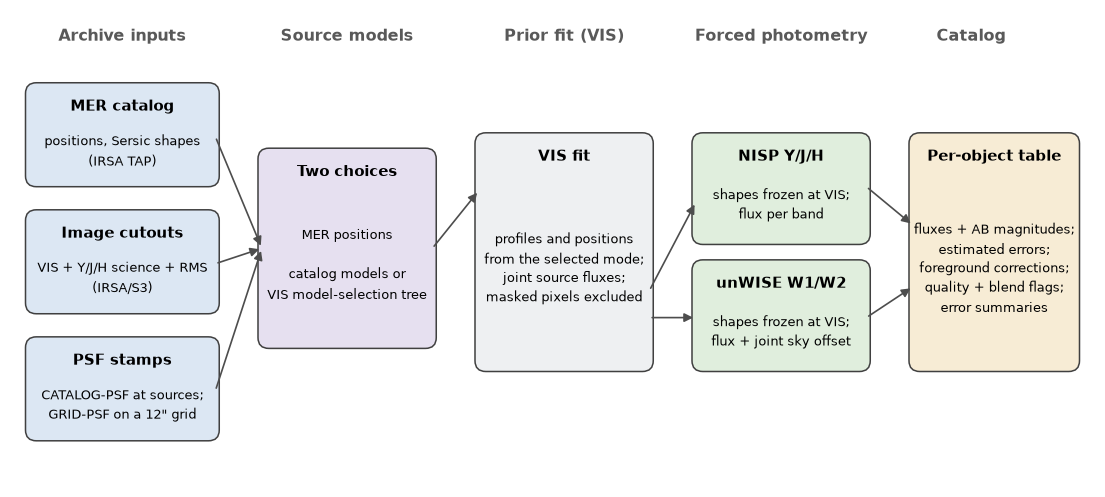

In [3]:
ep.viz.plot_workflow()
plt.show()


## 3. The MER catalog

The MER catalog supplies positions, point-likeness probabilities, and
available Sérsic parameters. This query selects rows with positive VIS
PSF flux. It reads the cached subset when present and queries IRSA otherwise.


In [4]:
mer_path = DATA_DIR / f"mer_catalog_{TARGET_RA:.4f}_{TARGET_DEC:.4f}_{int(CUTOUT_SIZE_ARCSEC)}.fits"
if mer_path.exists():
    mer_cat = Table.read(mer_path)
    print(f"loaded {len(mer_cat)} sources from {mer_path.name}")
else:
    half_size_deg = CUTOUT_SIZE_ARCSEC / 2.0 / 3600.0
    mer_cat = ep.query_mer_catalog(TARGET_RA, TARGET_DEC, half_size_deg)
    print(f"queried IRSA TAP: {len(mer_cat)} sources")


loaded 1120 sources from mer_catalog_269.4800_67.3000_200.fits


## 4. Fetching the Euclid cutouts

`fetch_cutout` copies the requested pixels from one MER tile and keeps
its pixel grid. Science, RMS and flags use the same tile as the PSFs.
The results are cached locally. A field extending beyond the selected
tile needs separate tile fits.

All four delivered MER mosaics have 0.1 arcsec pixels. Their PSFs differ:
about 0.2 arcsec FWHM in VIS and 0.5 arcsec in NISP, in the MER mosaics.


In [5]:
cutouts = {}
for band in ('VIS', 'Y', 'J', 'H'):
    cutouts[band] = ep.fetch_cutout(
        band, TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC,
        data_dir=DATA_DIR / "cutouts",
        with_flag=True)

for band, c in cutouts.items():
    print(f"  {band}: shape={c.shape}, pixel scale={c.pixel_scale_arcsec:.3f} arcsec/pix")

# A boundary source is clipped by the cutout (the `edge` flag of section 10),
# but its light must stay in the model or a neighbour absorbs it.
mer_cat = ep.trim_catalog_to_cutout(
    mer_cat, cutouts['VIS'].wcs, cutouts['VIS'].shape)
print(f"\non the image: {len(mer_cat)} sources")


  VIS: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  Y: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  J: shape=(2000, 2000), pixel scale=0.100 arcsec/pix
  H: shape=(2000, 2000), pixel scale=0.100 arcsec/pix

on the image: 1116 sources


The four bands of the same field.


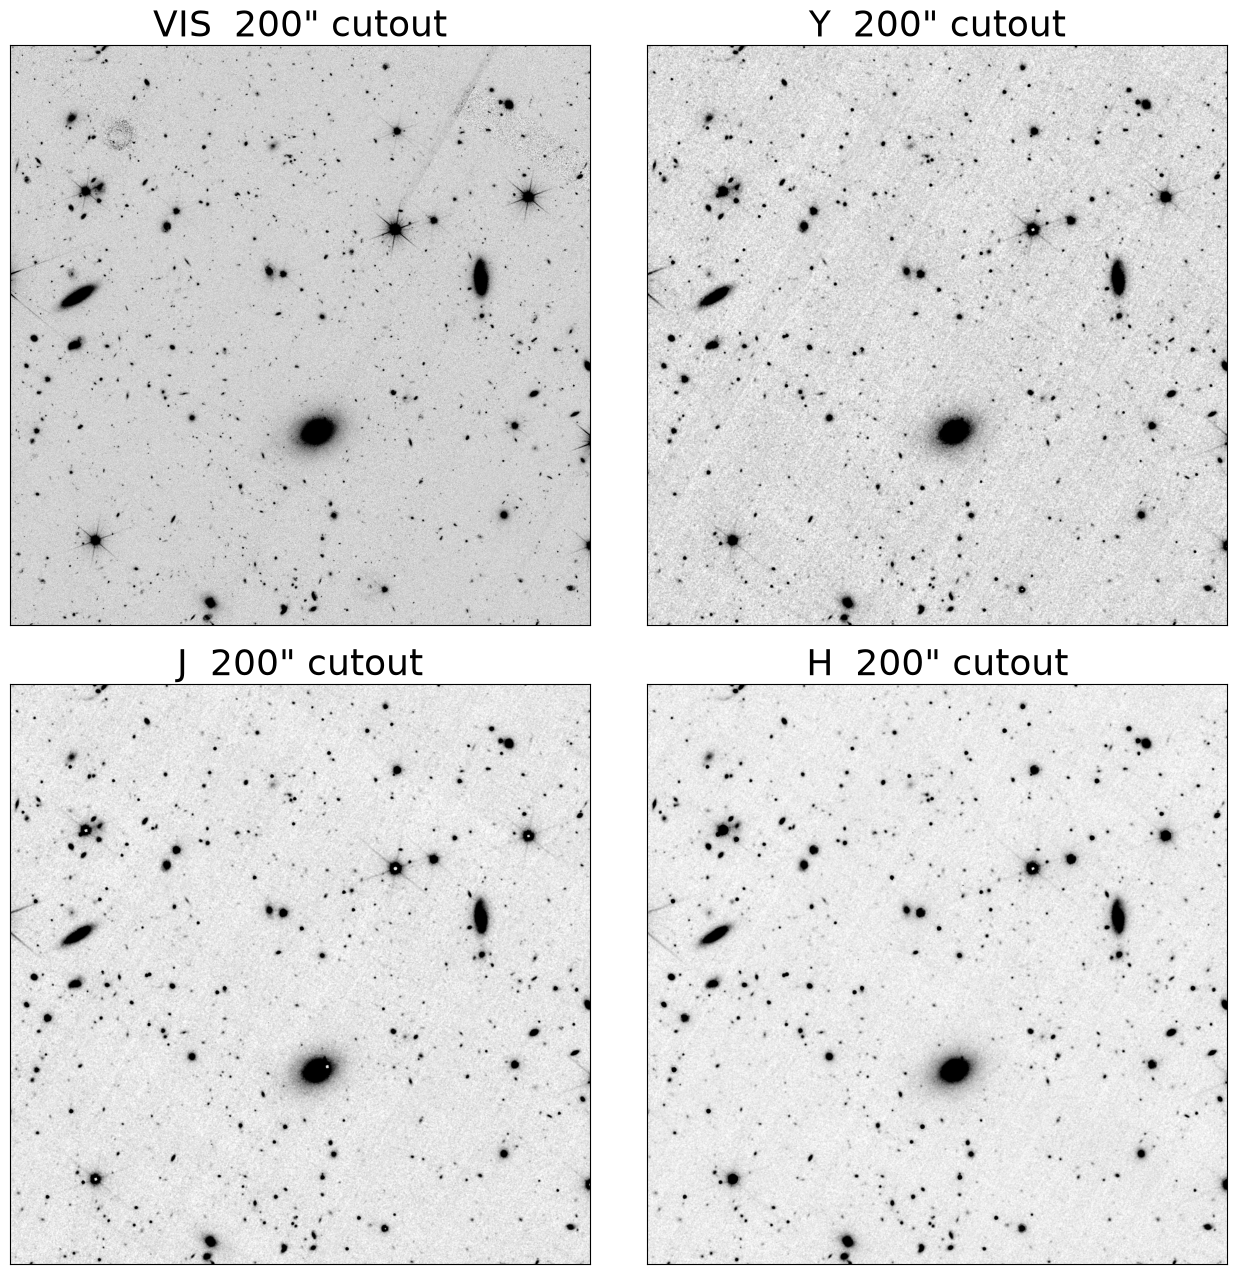

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, band in zip(axes.ravel(), ('VIS', 'Y', 'J', 'H')):
    ep.viz.show_cutout(cutouts[band], ax=ax,
                       title=f"{band}  {CUTOUT_SIZE_ARCSEC:.0f}\" cutout")
    ax.title.set_fontsize(26)
plt.tight_layout(); plt.show()


*These are the delivered MER mosaics on a common 0.1 arcsec grid;
NISP detector pixels are larger. The notebook fits the delivered pixels.*


## 5. The VIS PSF and the Tractor image

GRID-PSF contains samples evaluated on a regular grid; CATALOG-PSF contains
samples evaluated at MER catalogue positions. This tutorial uses GRID in
all Euclid bands. Each source uses its nearest sample, while overlapping
sources are fitted together. To compare products, change `PSF_PRODUCT`
below and restart the notebook.

In [7]:
PSF_PRODUCT = "grid"  # "catalog" is also supported
extract_psf = {"grid": ep.extract_grid_psf, "catalog": ep.extract_catalog_psf}[PSF_PRODUCT]

psf_data_vis = extract_psf(
    "VIS", TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
    tile_id=cutouts["VIS"].header.get("MERTILE"), data_dir=DATA_DIR / "psf")
psf_fwhm_vis = float(np.median(psf_data_vis["fwhm"]))
print(f"VIS {PSF_PRODUCT.upper()}-PSF: {len(psf_data_vis['stamps'])} stamps, "
      f"median FWHM = {psf_fwhm_vis:.3f} arcsec")

# Halos and diffraction spikes are real light the PSF stamp cannot model;
# the MER STARSIGNAL bit vetoes those pixels.
star_mask = ep.starsignal_pixel_mask(cutouts['VIS']) if MASK_BRIGHT_STARS else None
if star_mask is not None:
    print(f"STARSIGNAL bright-star mask: {int(star_mask.sum())} pixels "
          f"({100*star_mask.mean():.2f}%) excluded from the fit")

tim_vis = ep.build_tractor_image(
    cutouts['VIS'], psf_data=psf_data_vis, pixel_mask=star_mask)
_flg = cutouts['VIS'].flag
if _flg is not None:
    _nbad = int(((_flg & ep.MER_VIS_BAD_BITS) != 0).sum())
    print(f"VIS FLG plane attached; {_nbad} pixel(s) carry coadd-fatal bits "
          f"(INVALID/SAT/NO_DATA) and are excluded from the fit.")


VIS GRID-PSF: 486 stamps, median FWHM = 0.198 arcsec
STARSIGNAL bright-star mask: 70222 pixels (1.76%) excluded from the fit
VIS FLG plane attached; 2363 pixel(s) carry coadd-fatal bits (INVALID/SAT/NO_DATA) and are excluded from the fit.


### Spatial coverage of the selected PSF samples

The plot shows the sample positions, their FWHM, and the coverage of the
cutout. Nearest-sample selection does not interpolate between stamps, so
the local variation matters for extended sources.

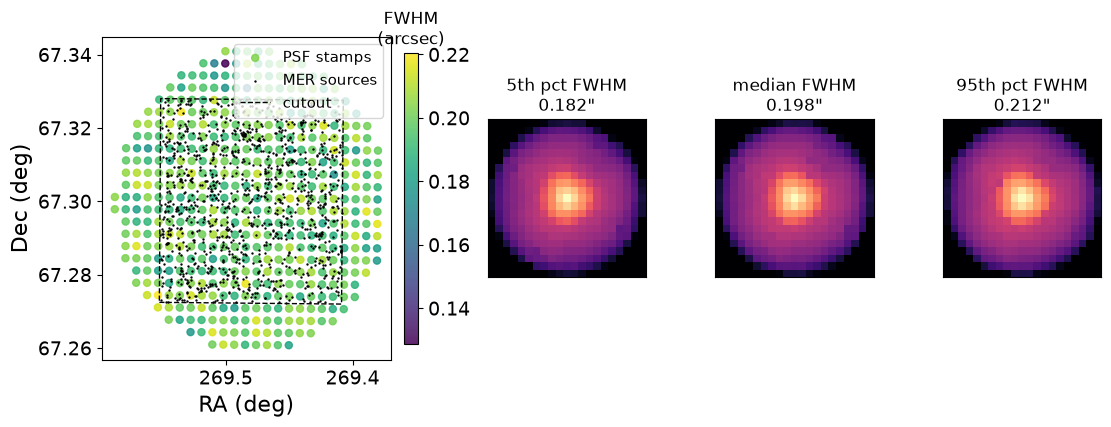

486 PSF samples, median spacing 12.0 arcsec
FWHM across the field: 0.129-0.221 arcsec (median 0.198)


In [8]:
fig, info = ep.viz.show_psf_grid(psf_data_vis, cutout=cutouts['VIS'],
                                 mer_cat=mer_cat)
plt.show()
print(f"{info['n_stamps']} PSF samples, median spacing "
      f"{info['median_spacing_arcsec']:.1f} arcsec")
print(f"FWHM across the field: {info['fwhm_min']:.3f}-"
      f"{info['fwhm_max']:.3f} arcsec (median {info['fwhm_median']:.3f})")


## 6. The source list

`model_selection="prior"` uses a point source when `point_like_prob > 0.96`
or the MER effective radius is smaller than half the VIS PSF FWHM;
otherwise it uses the available MER Sérsic shape, with an exponential fallback.

`model_selection="tree"` fits neighbouring sources together in image
regions detected by SEP. It compares point-source, fixed circular
exponential, exponential, de Vaucouleurs, and composite models using
reduced chi-squared. Resolved models with segment S/N ≥ 20 can also try
a free-index Sérsic model, retained for a total chi-squared improvement > 25.
This is an adaptation of [The Farmer](https://arxiv.org/abs/2310.07757);
[The model-selection notebook](supporting_notebooks/model_selection.ipynb) shows the model comparisons.

The tree also refines VIS positions, accepting shifts up to 0.3 arcsec.
A source outside the detected regions retains its MER prior. The output
stays aligned with the input catalog.


In [9]:
t0 = time.time()
if PRIOR["model_selection"] == "tree":
    print("Running the chi-squared decision tree on the prior image...")
    # Compare profile classes jointly with their neighbours on VIS.
    sources_list, _ = ep.run_model_selection(
        mer_cat, tim_vis,
        cutouts[PRIOR["band"]].data, tim_vis.getInvvar(),
        pixscale_arcsec=cutouts[PRIOR["band"]].pixel_scale_arcsec,
        n_workers=N_WORKERS,
    )
    # Rows the tree could not place fall back to their MER prior.
    fallback = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)
    sources = [s if s is not None else fb
               for s, fb in zip(sources_list, fallback)]
else:  # model_selection == "prior"
    print("Using the MER Sérsic catalog priors.")
    sources = ep.build_sources_from_mer(
        mer_cat, band=PRIOR["band"], psf_fwhm_arcsec=psf_fwhm_vis)

class_hist = {}
for s in sources:
    class_hist[type(s).__name__] = class_hist.get(type(s).__name__, 0) + 1
print(f"\nbuilt {len(sources)} sources in {time.time()-t0:.1f} s")
for k in sorted(class_hist):
    print(f"  {k:<22s} {class_hist[k]}")


Running the chi-squared decision tree on the prior image...



built 1116 sources in 191.5 s
  DevGalaxy              114
  ExpGalaxy              508
  FixedCompositeGalaxy   130
  PointSource            210
  SersicGalaxy           138
  SimpleGalaxy           16


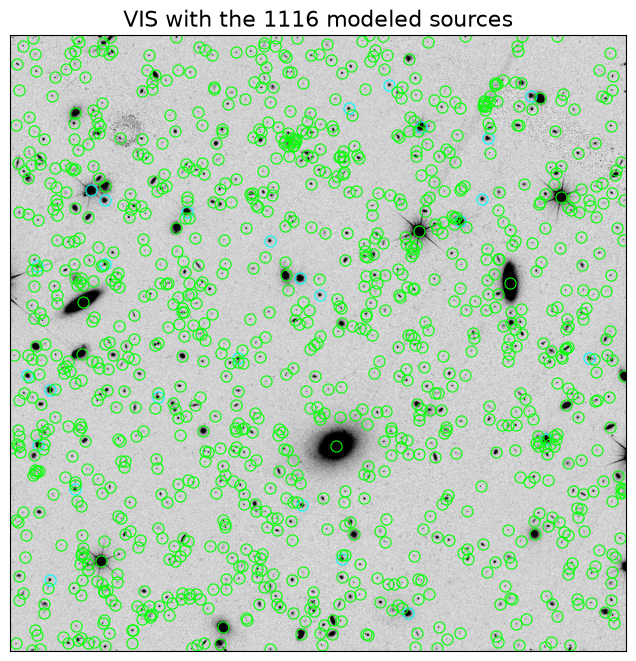

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ep.viz.show_cutout(cutouts['VIS'], mer_cat, ax=ax,
                   title=f"VIS with the {len(sources)} modeled sources")
plt.show()


*The modeled source list over the VIS prior image: cyan circles are
stars, green circles galaxies, following the MER classifier.*


## 7. Step 1: flux-only forced photometry

Freeze positions and shapes, then jointly fit source fluxes. The coarse
`fit_quality` guard rejects negative VIS flux or flux more than 100 times
a positive MER `flux_vis_sersic` reference; it is not a goodness-of-fit
test.

In [11]:
initial_vis_ujy = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)
tractor_vis, fit_quality, vis_err_ujy = ep.fit_forced_photometry(
    tim_vis, sources, band='VIS',
    initial_fluxes_ujy=initial_vis_ujy, return_errors=True,
)
print(f"VIS flux guard passed: {int(fit_quality.sum())}/{len(sources)} sources.")
print(f"median formal 1-sigma flux error (flux-only fit): "
      f"{np.nanmedian(vis_err_ujy[fit_quality]):.3f} microJansky")


VIS flux guard passed: 1107/1116 sources.
median formal 1-sigma flux error (flux-only fit): 0.019 microJansky


## 8. Step 2: free shapes for interior galaxies

For galaxies more than 50 pixels from the cutout edges, the shape
parameters (including the Sérsic ``n``) are re-optimized jointly with
brightness; positions remain fixed. The step is skipped when
``free_shapes`` is ``False``, and always in the decision-tree path:
the tree has already fitted each blob's shapes with the bounded
optimizer and shapes stay frozen thereafter.


In [12]:
if PRIOR["free_shapes"] and PRIOR["model_selection"] != "tree":
    fit_quality, n_thawed = ep.fit_free_shapes(
        tractor_vis, tim_vis, sources, fit_quality,
        band=PRIOR["band"], initial_fluxes_ujy=initial_vis_ujy,
    )
    print(f"Step 2 thawed shapes for {n_thawed} galaxies; "
          f"{int(fit_quality.sum())}/{len(sources)} sources pass the VIS flux guard.")
else:
    n_thawed = 0
    reason = ("the decision tree has already fit each blob's shapes with "
              "the bounded optimizer; they stay frozen"
              if PRIOR["model_selection"] == "tree"
              else "PRIOR['free_shapes']=False; shapes stay at the prior")
    print(f"Skipping step 2: {reason}.")

# Refined positions live on the source objects, so the NISP fits use them too.
if PRIOR.get("refine_positions"):
    fit_quality, n_refined, pos_shift_arcsec = ep.refine_positions(
        tractor_vis, tim_vis, sources, fit_quality, band=PRIOR["band"])
    _moved = pos_shift_arcsec[pos_shift_arcsec > 0]
    msg = (f"median shift {np.median(_moved) * 1000:.0f} mas"
           if len(_moved) else "no retained position shift")
    print(f"Refined {n_refined} positions (bounded to 0.2 arcsec); {msg}.")
else:
    pos_shift_arcsec = np.zeros(len(sources))
    print("Additional position refinement off; the selected VIS positions are retained.")
if n_thawed or PRIOR.get("refine_positions"):
    tractor_vis, final_quality, vis_err_ujy = ep.fit_forced_photometry(
        tim_vis, sources, band="VIS", initial_fluxes_ujy=initial_vis_ujy,
        return_errors=True,
    )
    fit_quality &= final_quality


Skipping step 2: the decision tree has already fit each blob's shapes with the bounded optimizer; they stay frozen.
Additional position refinement off; the selected VIS positions are retained.


## 9. VIS data, model, and residual

The residual is data minus model. Its brightness scale uses the median
formal pixel error; the chi map divides by each pixel's own error.
Correctly standardized noise has unit marginal variance, while pixel
correlations affect spatial structure and flux uncertainties.

Smooth profiles cannot reproduce every arm, bar, or clump. The finite
PSF stamps also omit extended stellar light. Masked pixels are gray;
stellar residuals outside the mask can still affect neighbouring sources.


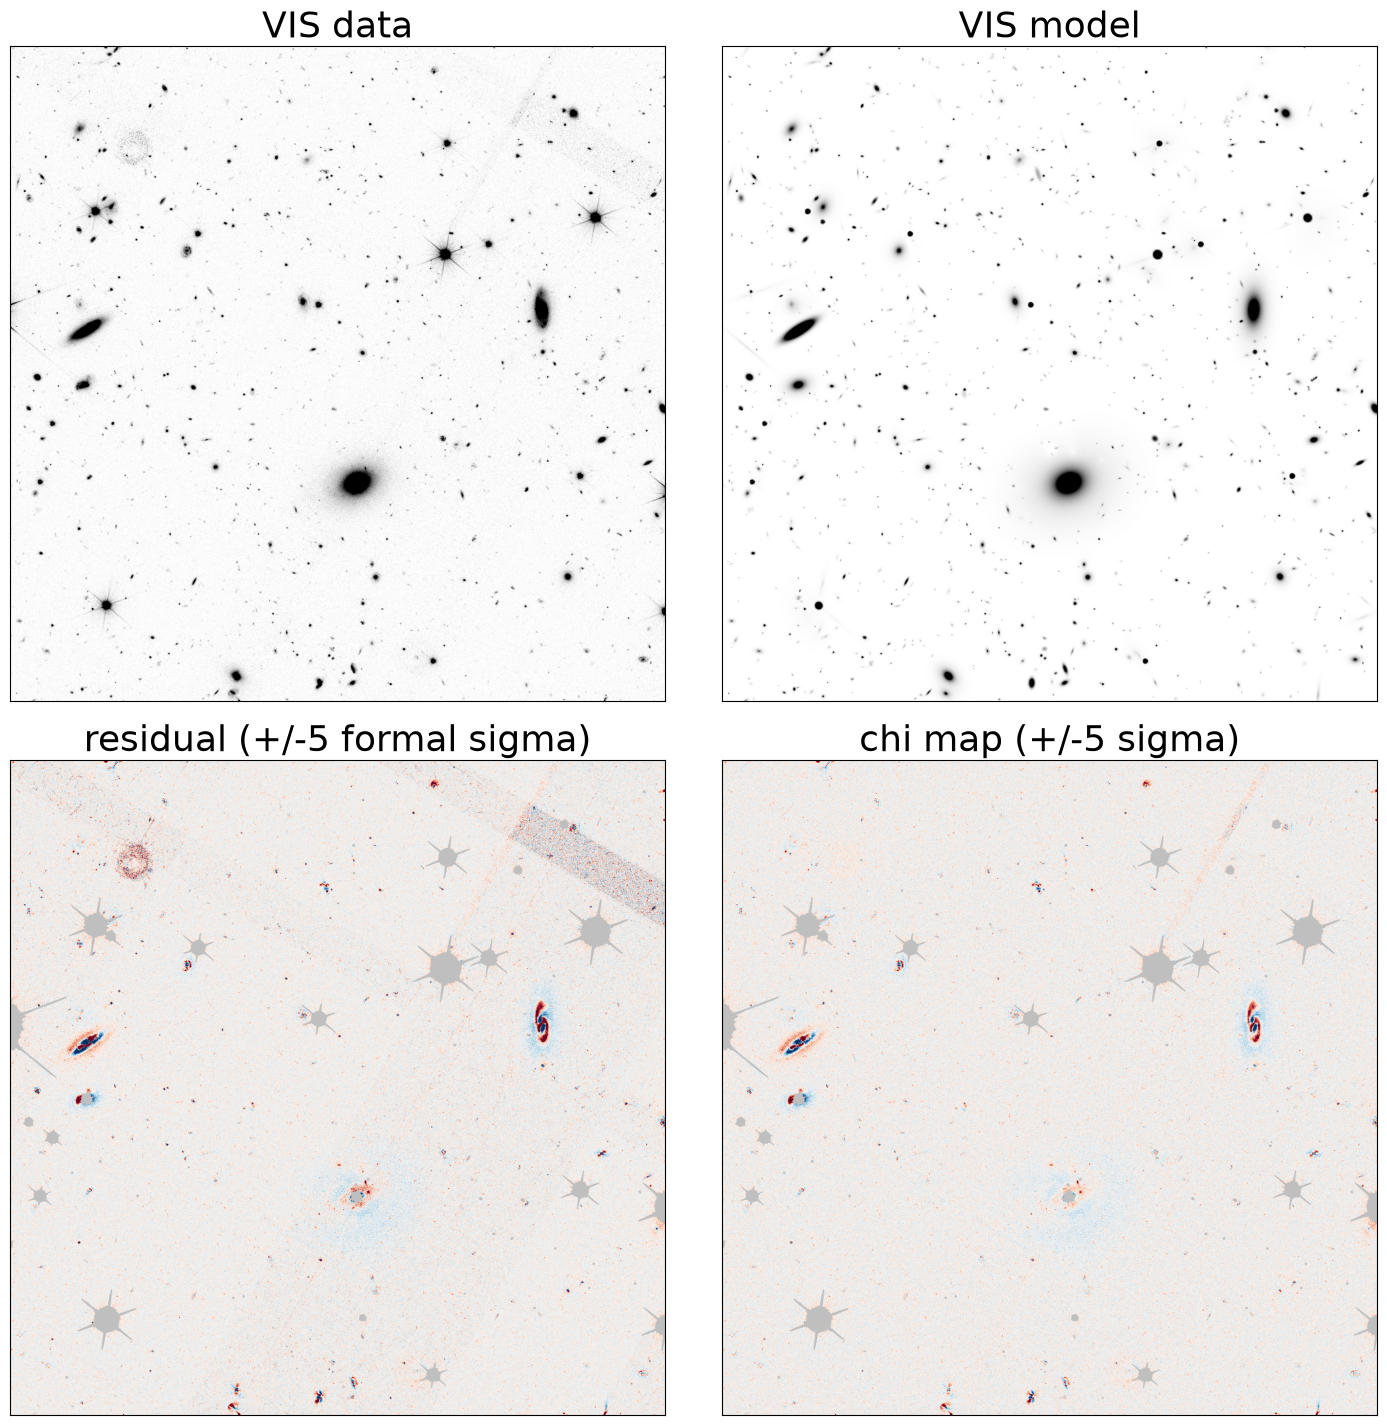

VIS formal per-pixel sigma:    0.0037457 counts
VIS empirical residual sigma:  0.0023892 counts
VIS chi std:                   0.709


In [13]:
res = ep.measure_residual(tractor_vis, tim_vis)
invvar_vis = tim_vis.getInvvar()

fig, axes = plt.subplots(2, 2, figsize=(14.5, 14.5))
vmax = float(np.nanpercentile(res['data'], 99.5))
axes[0, 0].imshow(res['data'],  origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 0].set_title('VIS data')
axes[0, 1].imshow(res['model'], origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0, 1].set_title('VIS model')
_, info_vis_res = ep.viz.show_residual(
    res['data'], res['model'], invvar=invvar_vis,
    ax=axes[1, 0], title='residual (+/-5 formal sigma)')
_, info_vis_chi = ep.viz.show_chi_map(
    res['data'], res['model'], invvar_vis,
    ax=axes[1, 1], title='chi map (+/-5 sigma)')
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.title.set_fontsize(26)
plt.tight_layout(); plt.show()

print(f"VIS formal per-pixel sigma:    {info_vis_res['formal_sigma']:.5g} counts")
print(f"VIS empirical residual sigma:  {info_vis_res['residual_std']:.5g} counts")
print(f"VIS chi std:                   {info_vis_chi['chi_std']:.3f}")

## 10. VIS: Tractor versus MER

Compare the fitted VIS flux with MER `flux_vis_psf` for catalog-classified
stars and `flux_vis_sersic` for the other sources. The source classes used
in our fit come from `PRIOR["model_selection"]`. Unconstrained sources are
excluded; sources near bright stars or the cutout edge are shown separately.


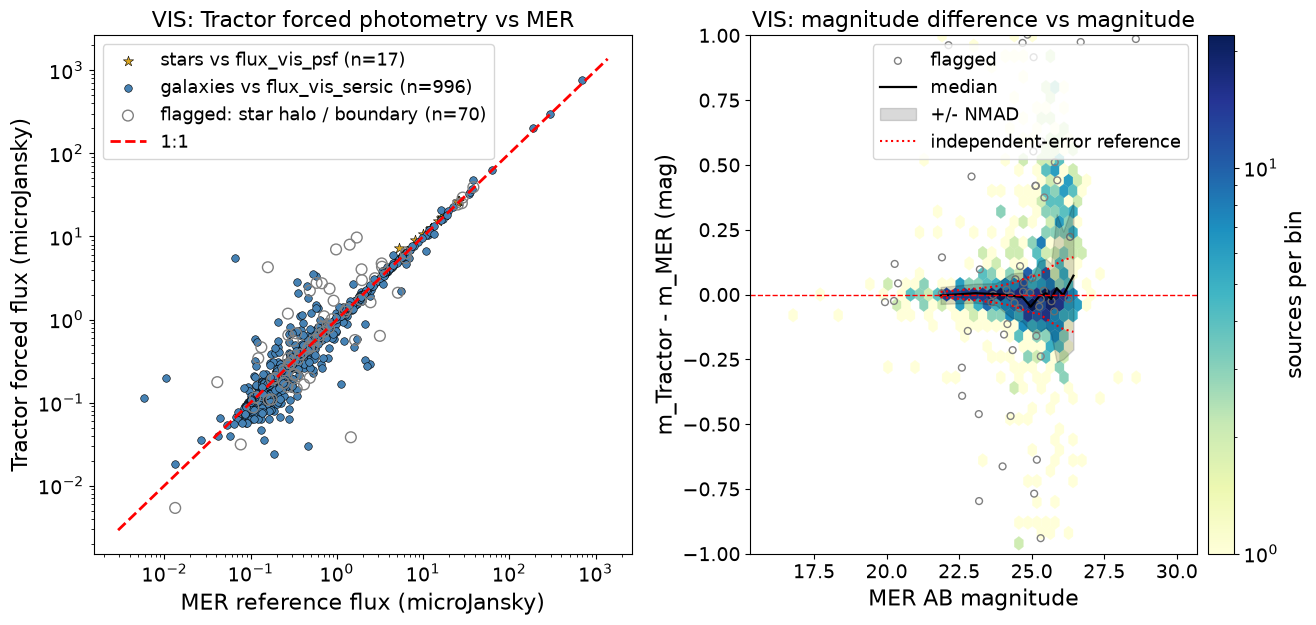

galaxies: median(Tractor / MER_sersic) = 1.001  (excluding flagged sources: 1.001, n=996)
median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:
  21.86 mag: median -0.004, NMAD 0.033
  23.06 mag: median +0.005, NMAD 0.037
  23.77 mag: median +0.001, NMAD 0.042
  24.30 mag: median -0.004, NMAD 0.085
  24.68 mag: median -0.010, NMAD 0.095
  24.96 mag: median -0.047, NMAD 0.094
  25.25 mag: median -0.008, NMAD 0.137
  25.49 mag: median +0.005, NMAD 0.132
  25.67 mag: median -0.017, NMAD 0.136
  25.86 mag: median +0.025, NMAD 0.285
  26.09 mag: median -0.003, NMAD 0.246
  26.44 mag: median +0.073, NMAD 0.284


In [14]:
tractor_vis_ujy = np.array(
    [s.brightness.getFlux('VIS') for s in sources]) * 3.631
is_star = np.asarray(mer_cat['is_star'], dtype=bool)
ref_star = np.asarray(mer_cat['flux_vis_psf'],    dtype=float)
ref_gal  = np.asarray(mer_cat['flux_vis_sersic'], dtype=float)

# Bright-star halos and clipped boundary profiles bias both axes; flag them
# so the plot and the medians separate them.
flags9 = ep.flag_sources(
    [s.getPosition().ra for s in sources], [s.getPosition().dec for s in sources],
    ref_star, ep.probable_bright_stars(mer_cat),
    wcs=cutouts['VIS'].wcs, shape=cutouts['VIS'].shape,
    flag_plane=cutouts['VIS'].flag)
contam = ~np.asarray(flags9['reliable'])

# A nan error means a fully masked source frozen at its seed, not a measurement.
measured = np.isfinite(vis_err_ujy)
m_s = fit_quality & measured & is_star  & (ref_star > 0) & (tractor_vis_ujy > 0)
m_g = fit_quality & measured & ~is_star & (ref_gal  > 0) & (tractor_vis_ujy > 0)

fig, (ax, axd) = plt.subplots(1, 2, figsize=(13.5, 6.5))
ax.scatter(ref_star[m_s & ~contam], tractor_vis_ujy[m_s & ~contam],
           c='goldenrod', marker='*', s=60, edgecolors='k', linewidths=0.4,
           label=f'stars vs flux_vis_psf (n={int((m_s & ~contam).sum())})')
ax.scatter(ref_gal[m_g & ~contam], tractor_vis_ujy[m_g & ~contam],
           c='steelblue', s=30, edgecolors='k', linewidths=0.4,
           label=f'galaxies vs flux_vis_sersic (n={int((m_g & ~contam).sum())})')
_xc = np.where(is_star, ref_star, ref_gal)
_mc = (m_s | m_g) & contam
ax.scatter(_xc[_mc], tractor_vis_ujy[_mc], facecolors='none',
           edgecolors='0.5', s=60, linewidths=1.0,
           label=f'flagged: star halo / boundary (n={int(_mc.sum())})')
all_x = np.concatenate([ref_star[m_s], ref_gal[m_g]])
if len(all_x):
    ax.plot([all_x.min()*0.5, all_x.max()*2],
            [all_x.min()*0.5, all_x.max()*2],
            'r--', lw=2, label='1:1')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('MER reference flux (microJansky)')
ax.set_ylabel('Tractor forced flux (microJansky)')
ax.legend()
ax.set_title('VIS: Tractor forced photometry vs MER')

ref = np.where(is_star, ref_star, ref_gal)
sel = m_s | m_g
_em_psf = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_psf'], float), np.nan)
_em_ser = np.ma.filled(np.ma.asarray(mer_cat['fluxerr_vis_sersic'], float), np.nan)
err_mer = np.where(is_star, _em_psf, _em_ser)
_, dstat = ep.viz.show_dmag_vs_mag(
    ref, tractor_vis_ujy, err_ujy=vis_err_ujy, ref_err_ujy=err_mer,
    sel=sel & ~contam, flagged=sel & contam, ax=axd,
    xlabel='MER AB magnitude', ylabel='m_Tractor - m_MER (mag)',
    title='VIS: magnitude difference vs magnitude')
axd.legend(fontsize=13)
plt.tight_layout(); plt.show()

med_g = float(np.median(tractor_vis_ujy[m_g] / ref_gal[m_g]))
m_gc = m_g & ~contam
med_gc = float(np.median(tractor_vis_ujy[m_gc] / ref_gal[m_gc]))
print(f"galaxies: median(Tractor / MER_sersic) = {med_g:.3f}  "
      f"(excluding flagged sources: {med_gc:.3f}, n={int(m_gc.sum())})")
print("median and NMAD of m_Tractor - m_MER in equal-count magnitude bins:")
for c, m, s in zip(dstat['centers'], dstat['median'], dstat['nmad']):
    print(f"  {c:5.2f} mag: median {m:+.3f}, NMAD {s:.3f}")


*The right panel shows median magnitude differences and NMAD scatter.
The dotted curve combines reported errors assuming independence; both
measurements use the same images, so it is only a reference scale.*


## 11. Inspect a source

Change `SOURCE_INDEX` and rerun the cell to view another source, without
refitting. Indices start at 0; try 166, 59 or 0 in this field.
The model includes neighbours. Gray residual pixels were excluded from fitting.


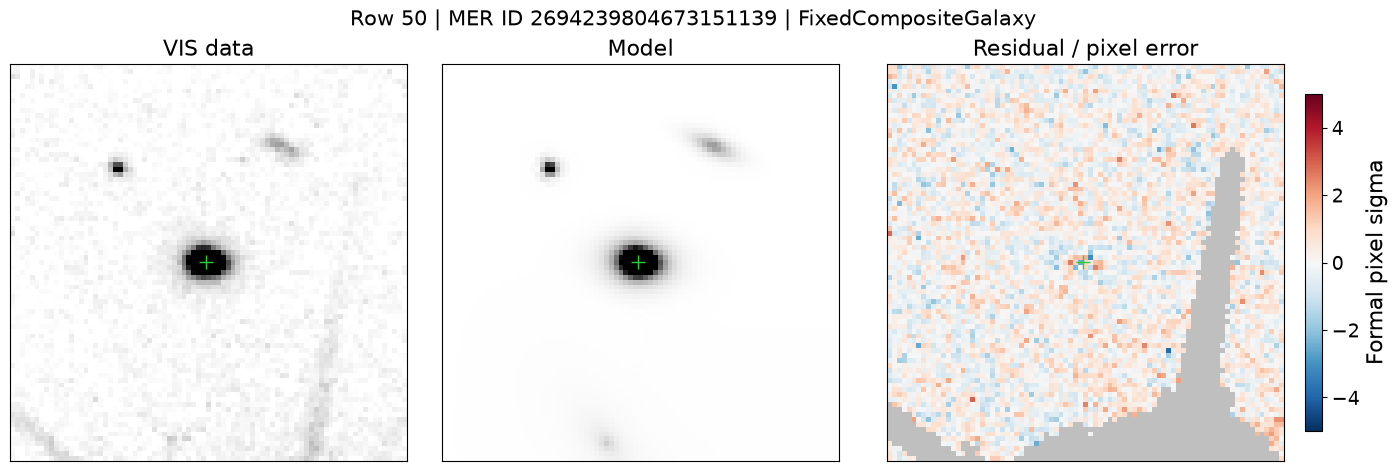

VIS flux guard passed: True; source flags: none
VIS fit: 6.545 +/- 0.043 microJansky (formal error)
MER Sérsic reference: 6.561 microJansky


In [15]:
SOURCE_INDEX = 50  # change this number and rerun this cell

if not isinstance(SOURCE_INDEX, (int, np.integer)) or not 0 <= SOURCE_INDEX < len(sources):
    raise ValueError(f"Choose an integer SOURCE_INDEX from 0 to {len(sources) - 1}.")
i = SOURCE_INDEX
quality = flags9

# Crop the existing data and full-scene model; no new fit is performed.
x, y = tim_vis.getWcs().positionToPixel(sources[i].getPosition())
xi, yi, half = int(round(x)), int(round(y)), 40
height, width = res['data'].shape
x0, x1 = max(0, xi - half), min(width, xi + half + 1)
y0, y1 = max(0, yi - half), min(height, yi + half + 1)
stamp = np.s_[y0:y1, x0:x1]
data, model, weight = res['data'][stamp], res['model'][stamp], tim_vis.getInvvar()[stamp]
vmax = max(float(np.nanpercentile(data, 99.5)), np.finfo(float).eps)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
for ax, pixels, title in zip(axes[:2], (data, model), ('VIS data', 'Model')):
    ax.imshow(pixels, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    ax.set_title(title)
ep.viz.show_chi_map(data, model, weight, ax=axes[2], title='Residual / pixel error')
fig.colorbar(axes[2].images[0], ax=axes[2], label='Formal pixel sigma', shrink=0.85)
for ax in axes:
    ax.plot(x - x0, y - y0, '+', color='limegreen', ms=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Row {i} | MER ID {int(mer_cat['object_id'][i])} | {type(sources[i]).__name__}", fontsize=15)
plt.show()

flags = [name for name in ('bright_star', 'near_bright_star', 'masked', 'edge') if quality[name][i]]
print(f"VIS flux guard passed: {bool(fit_quality[i])}; source flags: {', '.join(flags) or 'none'}")
if measured[i]:
    print(f"VIS fit: {tractor_vis_ujy[i]:.3f} +/- {vis_err_ujy[i]:.3f} microJansky (formal error)")
else:
    print("Flux unconstrained: the stored model amplitude is not a measurement.")
reference = ref_star[i] if is_star[i] else ref_gal[i]
print(f"MER {'PSF' if is_star[i] else 'Sérsic'} reference: {reference:.3f} microJansky")


## 12. Empirical calibration of the flux errors

Formal errors treat pixels as independent, while the delivered MER
mosaics contain correlated noise from resampling. We fit point-source
fluxes at empty positions and measure the scatter of flux/error, which
sets the error scale for point sources on this image. The one-call driver
performs this check with `calibrate_errors=True`.

VIS: 200 empty positions, flux/err scatter (chi_mad) = 0.792
     formal err median = 0.0075 uJy, empirical sigma = 0.0059 uJy
     adopted inflation = x1.000 (clamped at >= 1; errors are never deflated)


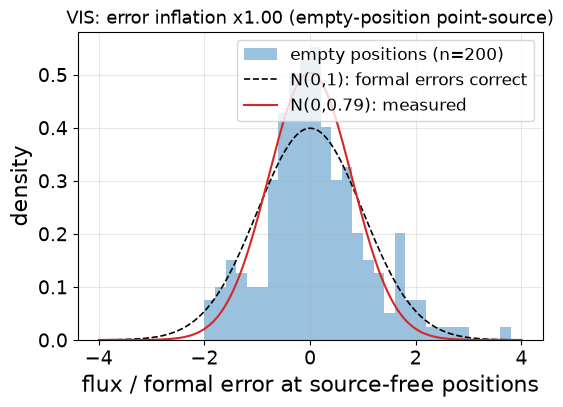

In [16]:
calib_vis = ep.measure_error_inflation(
    cutouts['VIS'], mer_cat=mer_cat, psf_data=psf_data_vis, band='VIS',
    n_positions=200, invvar=tim_vis.getInvvar(), rng=0)
print(f"VIS: {calib_vis['n_positions']} empty positions, "
      f"flux/err scatter (chi_mad) = {calib_vis['chi_mad']:.3f}")
print(f"     formal err median = {calib_vis['formal_err_med_ujy']:.4f} uJy, "
      f"empirical sigma = {calib_vis['empirical_sigma_ujy']:.4f} uJy")
print(f"     adopted inflation = x{calib_vis['inflation']:.3f} "
      f"(clamped at >= 1; errors are never deflated)")

ep.viz.show_error_calibration(calib_vis)
plt.show()

## 13. NISP PSFs

Use the same selected product for Y, J, and H. Each band supplies its own
stamps from the tile used for its science image; each source uses its
nearest sample in that band.


In [17]:
psf_data_nisp = {}
for band in ('Y', 'J', 'H'):
    psf_data_nisp[band] = extract_psf(
        band, TARGET_RA, TARGET_DEC, radius_arcsec=150.0,
        tile_id=cutouts[band].header.get('MERTILE'), data_dir=DATA_DIR / 'psf')
    fwhm = float(np.median(psf_data_nisp[band]['fwhm']))
    print(f"  NISP-{band} {PSF_PRODUCT.upper()}-PSF: {len(psf_data_nisp[band]['stamps'])} stamps, "
          f"median FWHM = {fwhm:.3f} arcsec")


  NISP-Y GRID-PSF: 486 stamps, median FWHM = 0.479 arcsec
  NISP-J GRID-PSF: 486 stamps, median FWHM = 0.503 arcsec
  NISP-H GRID-PSF: 486 stamps, median FWHM = 0.544 arcsec


## 14. Forced photometry in Y, J, and H

Carry the VIS positions and shapes to each NISP band. Render every source
with that band's local PSF and fit all fluxes together, keeping positions
and shapes fixed. The bright-star pixel mask is reused on the common
mosaic grid, and each band also excludes its own invalid and saturated
pixels.

In [18]:
t0 = time.time()
nisp_results = ep.fit_nisp_forced(
    sources,
    {b: cutouts[b]        for b in ('Y', 'J', 'H')},
    pixel_mask=star_mask,
    n_workers=N_WORKERS, psf_data=psf_data_nisp,
)
nisp_flux_ujy = {b: nisp_results[b]['flux_ujy']     for b in ('Y', 'J', 'H')}
nisp_err_ujy  = {b: nisp_results[b]['flux_err_ujy'] for b in ('Y', 'J', 'H')}
print(f"NISP forced phot done in {time.time()-t0:.1f} s")
for band in ('Y', 'J', 'H'):
    f = nisp_flux_ujy[band]
    print(f"  {band}: flux range {np.nanmin(f):.2f} to {np.nanmax(f):.0f} microJansky")

NISP forced phot done in 49.6 s
  Y: flux range -36.09 to 1452 microJansky
  J: flux range -57.65 to 1648 microJansky
  H: flux range -53.26 to 1961 microJansky


### NISP versus MER

Compare against MER `flux_<band>_templfit`, measured with T-PHOT.
Its image templates and flux definition differ from our smooth VIS profiles,
so this is a cross-check rather than a calibration target. The panels show
flux ratios and magnitude differences for positive fitted fluxes with formal
S/N > 5; medians and NMAD summarize that selected sample.

MER template-fit colors use `FLUX_VIS_TO_<band>_TEMPLFIT` as their VIS
reference, so the flux ratios here are not directly color offsets. See the
[MER cookbook](https://euclid.esac.esa.int/dr/q1/dpdd/merdpd/merphotometrycookbook.html).

Y: n=569, median(Tractor/MER_templfit) = 0.968, NMAD(dmag) = 0.124 mag
J: n=701, median(Tractor/MER_templfit) = 0.975, NMAD(dmag) = 0.128 mag
H: n=719, median(Tractor/MER_templfit) = 0.972, NMAD(dmag) = 0.115 mag


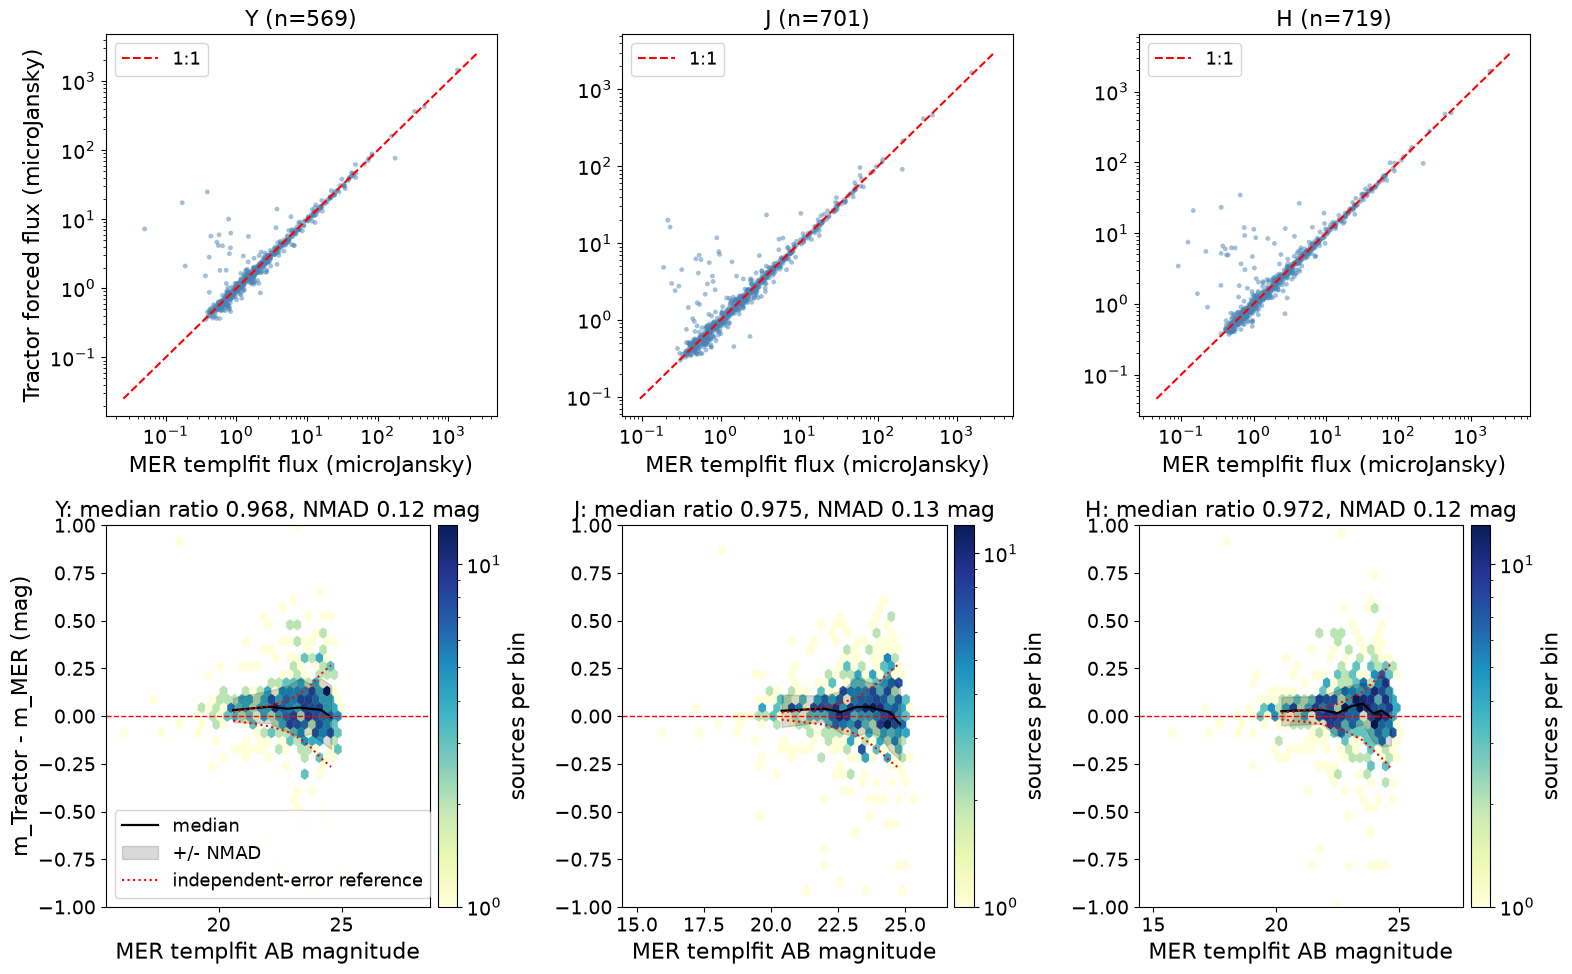

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for col, band in enumerate(('Y', 'J', 'H')):
    ours = np.asarray(nisp_flux_ujy[band], float)
    errs = np.asarray(nisp_err_ujy[band], float)
    ref_n = np.ma.filled(
        np.ma.asarray(mer_cat[f'flux_{band.lower()}_templfit'], float), np.nan)
    with np.errstate(invalid='ignore', divide='ignore'):
        snr = ours / errs
    ok = (fit_quality & np.isfinite(ours) & np.isfinite(ref_n)
          & (ref_n > 0) & (ours > 0) & (snr > 5))

    # Top: flux-flux relation against the 1:1 line.
    axf = axes[0, col]
    axf.scatter(ref_n[ok], ours[ok], s=12, c='steelblue', alpha=0.5,
                edgecolors='none')
    lims = (float(np.nanmin(ref_n[ok])) * 0.5,
            float(np.nanmax(ref_n[ok])) * 2.0)
    axf.plot(lims, lims, 'r--', lw=1.5, label='1:1')
    axf.set_xscale('log'); axf.set_yscale('log')
    axf.set_xlabel('MER templfit flux (microJansky)')
    axf.set_title(f'{band} (n={int(ok.sum())})')
    axf.legend(fontsize=13)

    # Bottom: magnitude difference vs magnitude through the same helper
    # as the VIS comparison in section 10.
    err_n = np.ma.filled(np.ma.asarray(
        mer_cat[f'fluxerr_{band.lower()}_templfit'], float), np.nan)
    med = float(np.median(ours[ok] / ref_n[ok]))
    nmad = float(mad_std(-2.5 * np.log10(ours[ok] / ref_n[ok])))
    ep.viz.show_dmag_vs_mag(
        ref_n, ours, err_ujy=errs, ref_err_ujy=err_n, sel=ok,
        ax=axes[1, col], gridsize=40, max_bins=12,
        xlabel='MER templfit AB magnitude',
        ylabel='m_Tractor - m_MER (mag)' if col == 0 else '',
        title=f'{band}: median ratio {med:.3f}, NMAD {nmad:.2f} mag')
    print(f"{band}: n={int(ok.sum())}, median(Tractor/MER_templfit) = "
          f"{med:.3f}, NMAD(dmag) = {nmad:.3f} mag")
axes[0, 0].set_ylabel('Tractor forced flux (microJansky)')
axes[1, 0].legend(fontsize=13, loc='lower left')
plt.tight_layout(); plt.show()


## 15. The multi-band catalog

`ForcedPhotometryResult.to_table()` creates one row per source with flux
density, estimated uncertainty, AB magnitude, model class, and quality
flags, plus extinction-corrected magnitudes and the calibration factors in
its metadata. Flux densities are in microJansky, with
`m_AB = 23.9 - 2.5 log10(flux_uJy)` for positive fluxes; non-positive
fluxes have no AB magnitude, and unconstrained measurements are NaN.
`reliable` covers the geometric VIS checks of section 10. Rows failing the
VIS flux guard are NaN in all bands, so this is a VIS-selected catalog.

The saved CSV keeps the rows with a measured VIS flux and the columns of
an ordinary photometry catalog: identifier, position, model class, the
`reliable` flag, and flux and magnitude with their errors per band.

In [20]:
from euclid_phot import ForcedPhotometryResult

fluxes = {'VIS': tractor_vis_ujy, **nisp_flux_ujy}
errors = {'VIS': vis_err_ujy, **nisp_err_ujy}
for band in fluxes:
    fluxes[band] = np.where(fit_quality, fluxes[band], np.nan)
    errors[band] = np.where(fit_quality, errors[band], np.nan)

result = ForcedPhotometryResult(
    target=(TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC),
    prior=dict(PRIOR), target_bands=dict(TARGET_BANDS),
    mer_cat=mer_cat, sources=sources,
    cutouts=cutouts,
    psf_data={"VIS": psf_data_vis, **psf_data_nisp},
    psf_mode="nearest-source-position",
    prior_pixel_mask=star_mask,
    fluxes_ujy=fluxes, flux_errs_ujy=errors,
    flux_quality=fit_quality,
    chosen_models=[type(s).__name__ for s in sources],
    data_dir=DATA_DIR,
)

# The section 12 calibration for every Euclid band; the factors go to the metadata.
ep.calibrate_result_errors(result, verbose=True)

catalog = result.to_table()
print(f"\n{len(catalog)} sources x {len(catalog.colnames)} columns")
print(f"error inflation: {catalog.meta['error_inflation']}")
print(f"5 x median-error equivalents (AB): {catalog.meta['depth_5sigma_ab']}")

keep = ['object_id', 'ra', 'dec', 'model', 'reliable'] + [
    c for c in catalog.colnames
    if c.startswith(('flux_', 'mag_')) and not c.endswith(('_extcorr', '_quality'))]
has_vis = np.isfinite(np.asarray(catalog['flux_VIS_ujy'], dtype=float))
catalog[keep][has_vis].write('forced_photometry_catalog.csv', overwrite=True)
print(f"wrote {int(has_vis.sum())} sources x {len(keep)} columns to forced_photometry_catalog.csv")

preview = catalog[np.isfinite(np.asarray(catalog['mag_VIS_ab']))].copy()
preview.sort('flux_VIS_ujy')
preview[['object_id', 'ra', 'dec', 'model', 'flux_VIS_ujy', 'mag_VIS_ab',
         'mag_Y_ab', 'mag_J_ab', 'mag_H_ab', 'reliable']][-8:].pprint_all()

  VIS: error inflation x1.00 (empty-position point-source, n=200)


  Y: error inflation x1.07 (empty-position point-source, n=200)


  J: error inflation x1.00 (empty-position point-source, n=200)
  H: error inflation x1.00 (empty-position point-source, n=199)



1116 sources x 39 columns
error inflation: {'VIS': 1.0, 'Y': 1.0694, 'J': 1.0, 'H': 1.0}
5 x median-error equivalents (AB): {'VIS': 26.456, 'Y': 24.447, 'J': 24.589, 'H': 24.504}
wrote 1095 sources x 21 columns to forced_photometry_catalog.csv
     object_id              ra                dec               model            flux_VIS_ujy        mag_VIS_ab          mag_Y_ab           mag_J_ab           mag_H_ab      reliable
                           deg                deg                                    uJy                mag                mag                mag                mag                 
------------------- ------------------ ----------------- -------------------- ------------------ ------------------ ------------------ ------------------ ------------------ --------
2694298060672825982  269.4298060020891 67.28259829315955         SersicGalaxy  34.08571821808835 20.068568876441475 19.199185294224144 18.922929821130825  18.68750368857377     True
2694276073673218949  269.42